## Define Metrics
- ROC-AUC
- F1 Score
- Recall
- Precision 
- Confusion Matrix

# Loading Data

In [2]:
# import modules
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from core.data import load_from_kaggle
from sklearn.ensemble import IsolationForest
from scipy.stats import chi2_contingency

c:\Users\Jaeden Capinig\Documents\DPP-Projekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# gathering data from Kaggle
dataset_link = "zkskhurram/lung-cancer-clinical-dataset-20152025" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\lung-cancer-clinical-dataset-20152025' already exists with files. Skipping download (replace=False).


In [4]:
files

['dataset_metadata.json', 'lung_cancer_dataset.csv']

# EDA
**Dataset**: Lung Cancer Global Clinical & Risk Factor Dataset (2015–2025)

**Records**: 1,500 patients 
**Features**: 41 

**Target**: `Survived`(binary)

**Goals:**
- Understand the structure and quality of the data
- Identify key predictors of survival
- Detect outliers and class imbalance
- Inform feature selection and preprocessing decisions

In [5]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[1]]))
df.sample(10)

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,...,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
88,LC-0089,2016,2016-07-07,South-East Asia,Bangladesh,71,Male,Never Smoked,0,0,...,No,NSCLC,Squamous Cell,Stage IV,7.6,Yes,Bronchoscopy,Targeted Therapy,11,No
1356,LC-1357,2018,2018-01-05,Americas,Argentina,51,Female,Never Smoked,0,0,...,Yes,NSCLC,Large Cell,Stage II,4.2,No,Bronchoscopy,Surgery + Chemotherapy,6,No
89,LC-0090,2022,2022-02-22,Americas,Chile,53,Male,Current Smoker,34,15,...,No,NSCLC,Adenocarcinoma,Stage IV,8.2,Yes,Bronchoscopy,Chemo + Radiation,4,No
684,LC-0685,2024,2024-08-03,Europe,Germany,63,Male,Former Smoker,30,21,...,No,NSCLC,Large Cell,Stage I,3.3,No,CT Scan,Surgery,54,No
274,LC-0275,2022,2022-01-28,South-East Asia,Nepal,30,Female,Never Smoked,0,0,...,No,NSCLC,Adenocarcinoma,Stage II,3.4,No,PET Scan,Surgery + Chemotherapy,25,Yes
1345,LC-1346,2018,2018-12-20,Western Pacific,Australia,52,Male,Never Smoked,0,0,...,No,SCLC,Not Applicable,Stage II,3.7,No,Biopsy,Targeted Therapy,48,No
903,LC-0904,2018,2018-12-06,Western Pacific,China,64,Male,Never Smoked,0,0,...,No,NSCLC,Large Cell,Stage II,4.4,No,MRI,Targeted Therapy,34,Yes
50,LC-0051,2022,2022-10-15,Africa,Algeria,43,Female,Never Smoked,0,0,...,No,NSCLC,Adenocarcinoma,Stage III,4.7,Yes,Biopsy,Targeted Therapy,24,No
506,LC-0507,2017,2017-08-15,South-East Asia,Sri Lanka,76,Female,Current Smoker,26,26,...,Yes,NSCLC,Squamous Cell,Stage IV,8.1,Yes,CT Scan,Palliative Care,11,No
61,LC-0062,2021,2021-03-18,Western Pacific,Singapore,54,Female,Never Smoked,0,0,...,No,NSCLC,Squamous Cell,Stage I,2.4,No,LDCT Screening,Surgery,63,Yes


**Qucik observations**
- many columns contain 'Yes'/'No' values including target variable
- according to metadata.json, `Survival Months` leaks target. to exclude in modeling
- `Patient_ID` and `Diagnosis_Date/Year` are only informative. to also remove

## Understanding the data

In [6]:
pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique()
    })


,Data Types,Missing Values,Unique Values
Patient_ID,object,0,1500
Diagnosis_Year,int64,0,11
Diagnosis_Date,object,0,1222
WHO_Region,object,0,6
Country,object,0,60
Age,int64,0,57
Gender,object,0,2
Smoking_Status,object,0,3
Cigarettes_Per_Day,int64,0,47
Years_Smoking,int64,0,52


### Data quality
- no missing values
- cat_cols will undergo OneHotEncoding, dropping cols with many unique values

In [7]:
# checking objects
cat_cols = df.select_dtypes(include='object').drop(columns=['Patient_ID', 'Diagnosis_Date'])

for col in cat_cols:
    print(f"{df.loc[:, col].value_counts()}\n")

WHO_Region
Western Pacific          465
Europe                   298
Americas                 255
South-East Asia          228
Eastern Mediterranean    164
Africa                    90
Name: count, dtype: int64

Country
New Zealand     56
Japan           53
Vietnam         53
Malaysia        50
Mongolia        48
Philippines     47
Australia       45
South Korea     40
Russia          39
China           38
Turkey          36
Singapore       35
Netherlands     35
Germany         34
Canada          31
Indonesia       31
Poland          31
Bangladesh      30
Peru            28
Argentina       28
Brazil          27
Spain           26
Colombia        26
Timor-Leste     26
Chile           26
Cuba            26
Italy           25
Sweden          25
France          24
Bhutan          24
Mexico          23
UK              23
Iran            22
Maldives        22
Lebanon         21
USA             20
India           20
Venezuela       20
Nepal           19
Qatar           19
Oman            19
T

- mild imbalanced for target variable 'Survived' with 63/37

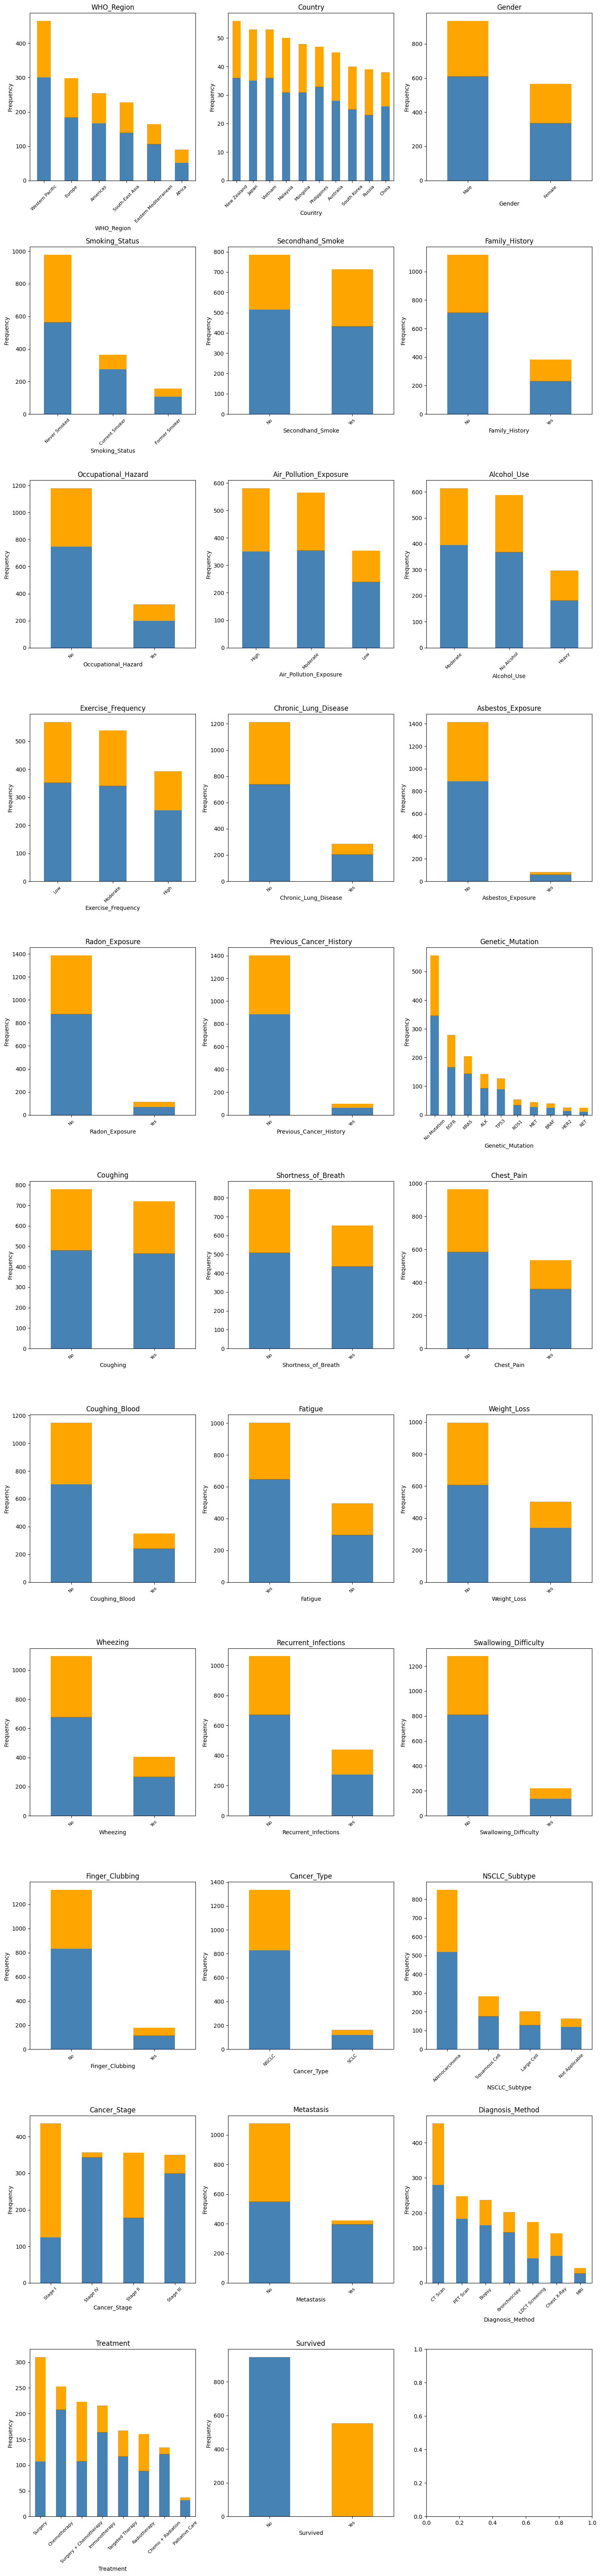

In [8]:
# Create barplots for categorical columns
n_cols = len(cat_cols.columns)
fig, axs = plt.subplots(nrows=n_cols // 3 + 1, ncols=3, figsize=(15, n_cols * 2))
axs = axs.flatten()

for idx, col in enumerate(cat_cols.columns):
    top_cats = df[col].value_counts().head(10).index
    data = df[df[col].isin(top_cats)].groupby([col, 'Survived']).size().unstack(fill_value=0).reindex(top_cats)
    data.plot(kind='bar', stacked=True, ax=axs[idx], color=['steelblue', 'orange'], legend=False)
    axs[idx].set_title(col, fontsize=12)
    axs[idx].set_ylabel('Frequency')
    axs[idx].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

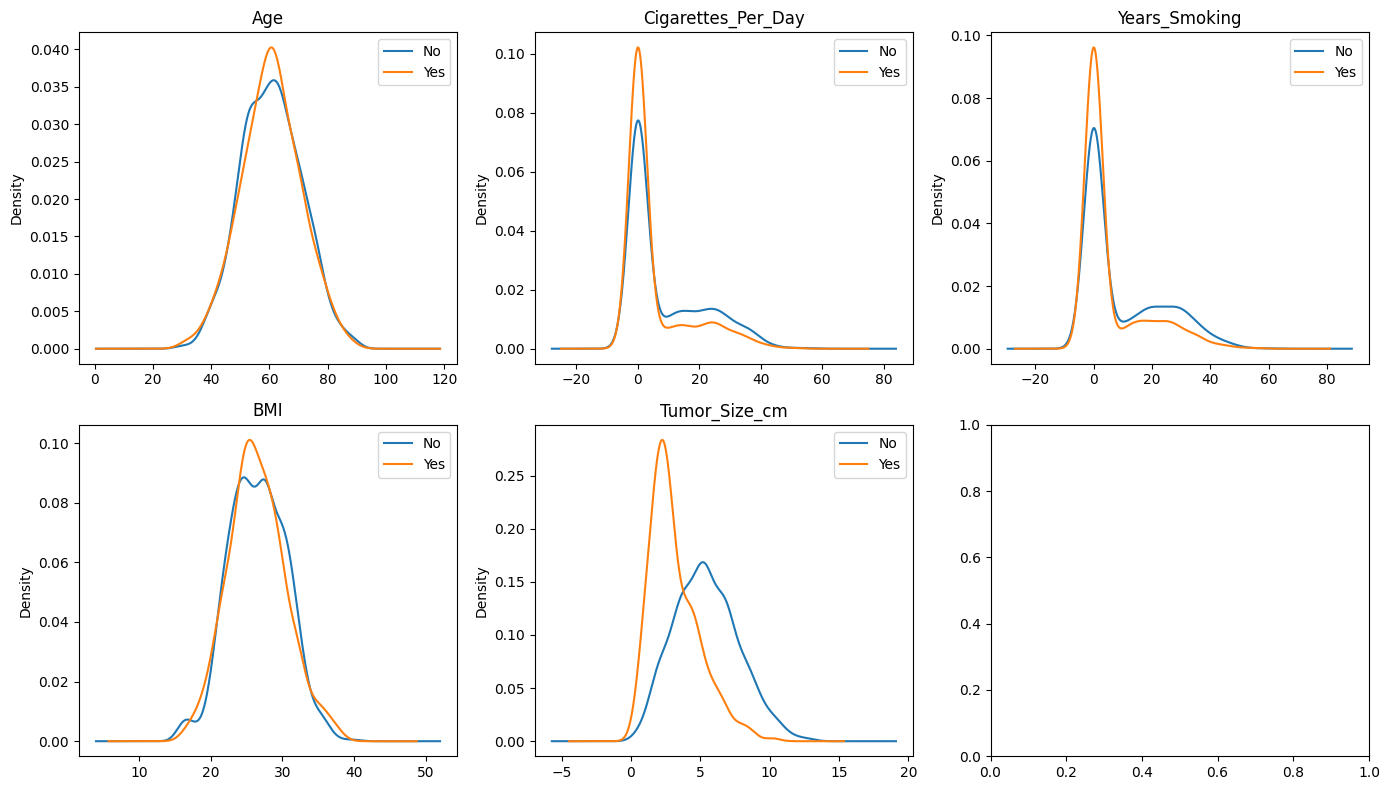

In [9]:
# checking distribution for numerical columns
num_cols = ['Age', 'Cigarettes_Per_Day', 'Years_Smoking',
            'BMI', 'Tumor_Size_cm']

fig, axes = plt.subplots(2, 3, figsize=(14,8))
for ax, col in zip(axes.flatten(), num_cols):
    for label, grp in df.groupby('Survived'):
        grp[col].plot(kind='kde', ax=ax, label=label)
        ax.set_title(col); ax.legend()
plt.tight_layout()

In [10]:
# checking in which cancer stage a patient survived or did not
pd.crosstab(df['Cancer_Stage'], 
            df['Survived'], 
            normalize='index').round(2)

Survived,No,Yes
Cancer_Stage,,
Stage I,0.29,0.71
Stage II,0.50,0.50
Stage III,0.85,0.15
Stage IV,0.96,0.04


- as `Cancer_Stage` increases, survival rate drops

In [11]:
# check distibution
# fig = sns.pairplot(data=df, hue='Survived')
# fig
# plt.savefig('eda_pairplot.png')

In [12]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)

'Shape'

(1500, 41)

'Description'

,count,mean,std,min,25%,50%,75%,max
Diagnosis_Year,1500.0,2020.63,3.10,2015.0,2018.0,2021.00,2023.0,2025.0
Age,1500.0,60.66,10.30,30.0,53.0,60.00,68.0,89.0
Cigarettes_Per_Day,1500.0,7.40,11.80,0.0,0.0,0.00,14.0,56.0
Years_Smoking,1500.0,8.21,12.78,0.0,0.0,0.00,17.0,59.0
BMI,1500.0,26.54,3.98,16.0,23.8,26.45,29.4,40.0
Tumor_Size_cm,1500.0,4.59,2.39,0.5,2.6,4.40,6.2,12.9
Survival_Months,1500.0,31.15,23.27,1.0,11.0,26.00,48.0,109.0


'Duplicates'

np.int64(0)

## Detecting outliers

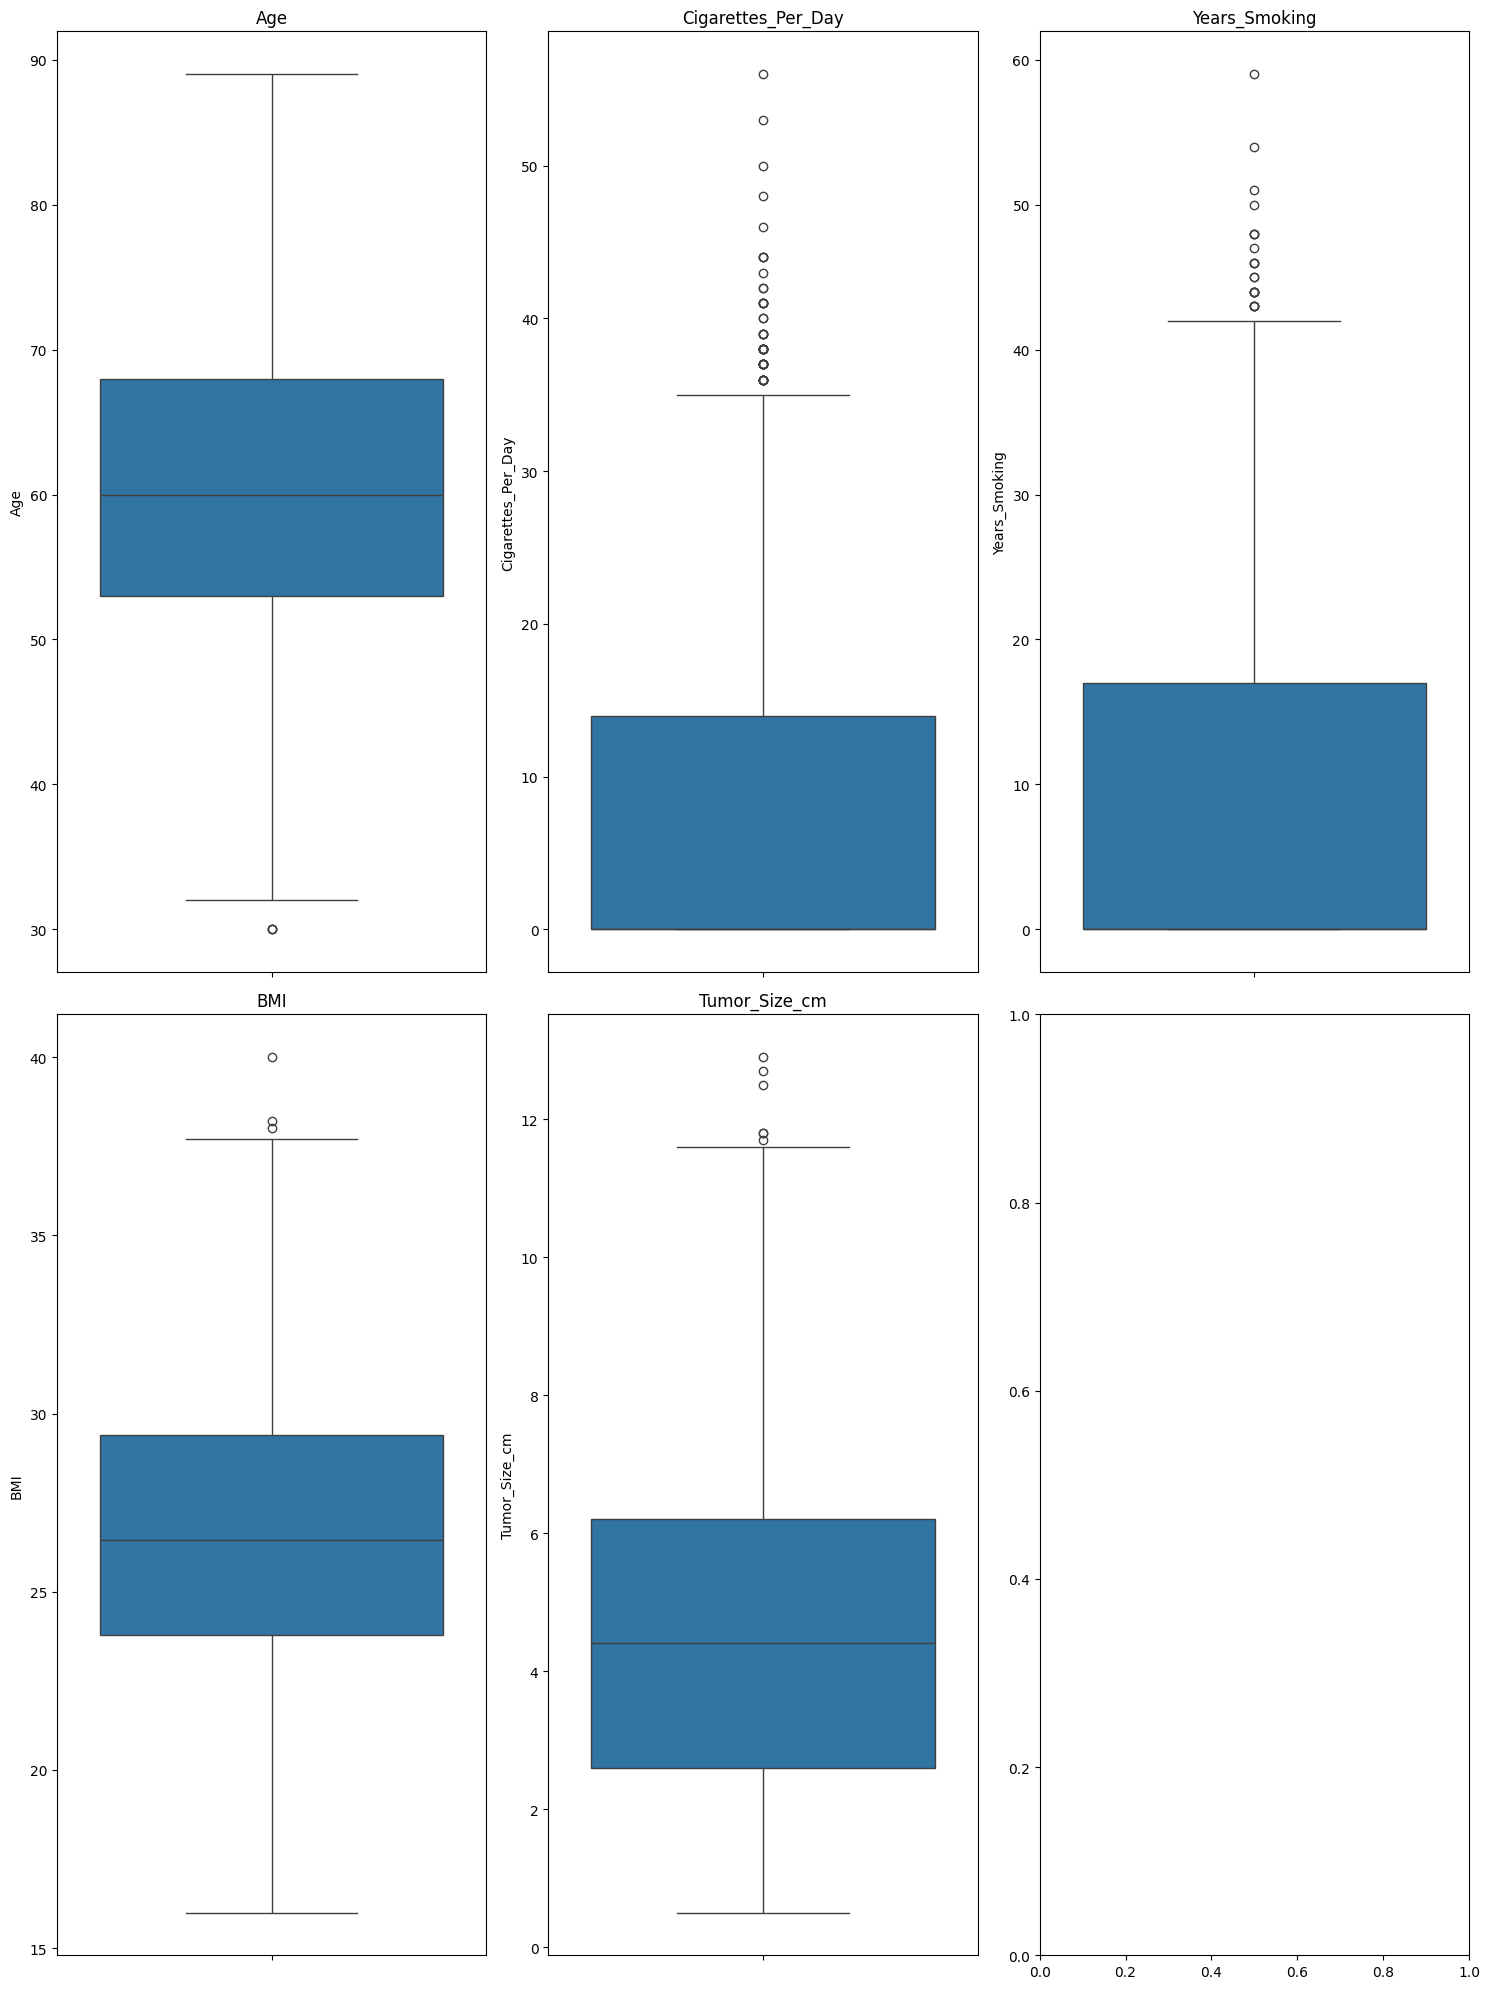

In [20]:
# Boxplots to visualise outliers
fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

- for num_cols, `Cigarettes_Per_Day` and `Years_Smoking` has numerous outliers

In [13]:
# implementing IQR to detect outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers\n")

Age: 3 outliers

Cigarettes_Per_Day: 48 outliers

Years_Smoking: 22 outliers

BMI: 3 outliers

Tumor_Size_cm: 6 outliers



In [ ]:
iso = IsolationForest(contamination=0.05, random_state=0)
df['outlier'] = iso.fit_predict(df[num_cols])
print(df['outlier'].value_counts())
# -1 = outlier, 1 = normal

outlier
 1    1425
-1      75
Name: count, dtype: int64


- IQR flagged outliers mostly in Cigarettes_Per_Day, representing heavy smokers
- to retain all outliers, as models such as Random Forest handle outliers well

In [15]:
# View a sample of 75 outlier rows                                                   df_outliers = df[df['outlier'] == -1]                                      
df_outliers = df[df['outlier'] == -1]
df_outliers.sample(5)

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,...,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived,outlier
410,LC-0411,2024,2024-02-17,Western Pacific,New Zealand,49,Female,Current Smoker,24,16,...,NSCLC,Adenocarcinoma,Stage I,3.1,No,Chest X-Ray,Surgery + Chemotherapy,80,Yes,-1
732,LC-0733,2018,2018-06-17,Americas,Brazil,75,Male,Current Smoker,38,38,...,NSCLC,Adenocarcinoma,Stage III,4.4,Yes,Bronchoscopy,Chemo + Radiation,17,No,-1
437,LC-0438,2023,2023-11-14,Eastern Mediterranean,Iraq,74,Male,Current Smoker,29,45,...,SCLC,Not Applicable,Stage IV,5.9,Yes,Biopsy,Targeted Therapy,3,No,-1
198,LC-0199,2023,2023-11-07,Africa,Algeria,38,Female,Former Smoker,9,8,...,SCLC,Not Applicable,Stage II,2.9,No,PET Scan,Chemotherapy,39,No,-1
913,LC-0914,2024,2024-06-10,Americas,Venezuela,73,Male,Current Smoker,44,29,...,NSCLC,Squamous Cell,Stage III,8.7,No,Bronchoscopy,Chemotherapy,28,No,-1


In [19]:
# to see which are extreme values
df_outliers[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,75.0,66.560000,14.238547,38.0,52.50,71.0,76.00,89.0
Cigarettes_Per_Day,75.0,24.840000,12.613849,0.0,16.00,27.0,34.50,53.0
Years_Smoking,75.0,30.080000,14.092129,0.0,21.00,30.0,42.00,59.0
BMI,75.0,27.468000,5.035983,16.0,23.95,28.0,31.35,36.3
Tumor_Size_cm,75.0,5.102667,3.543055,0.5,2.05,4.7,7.80,12.9


## Checking Correlations

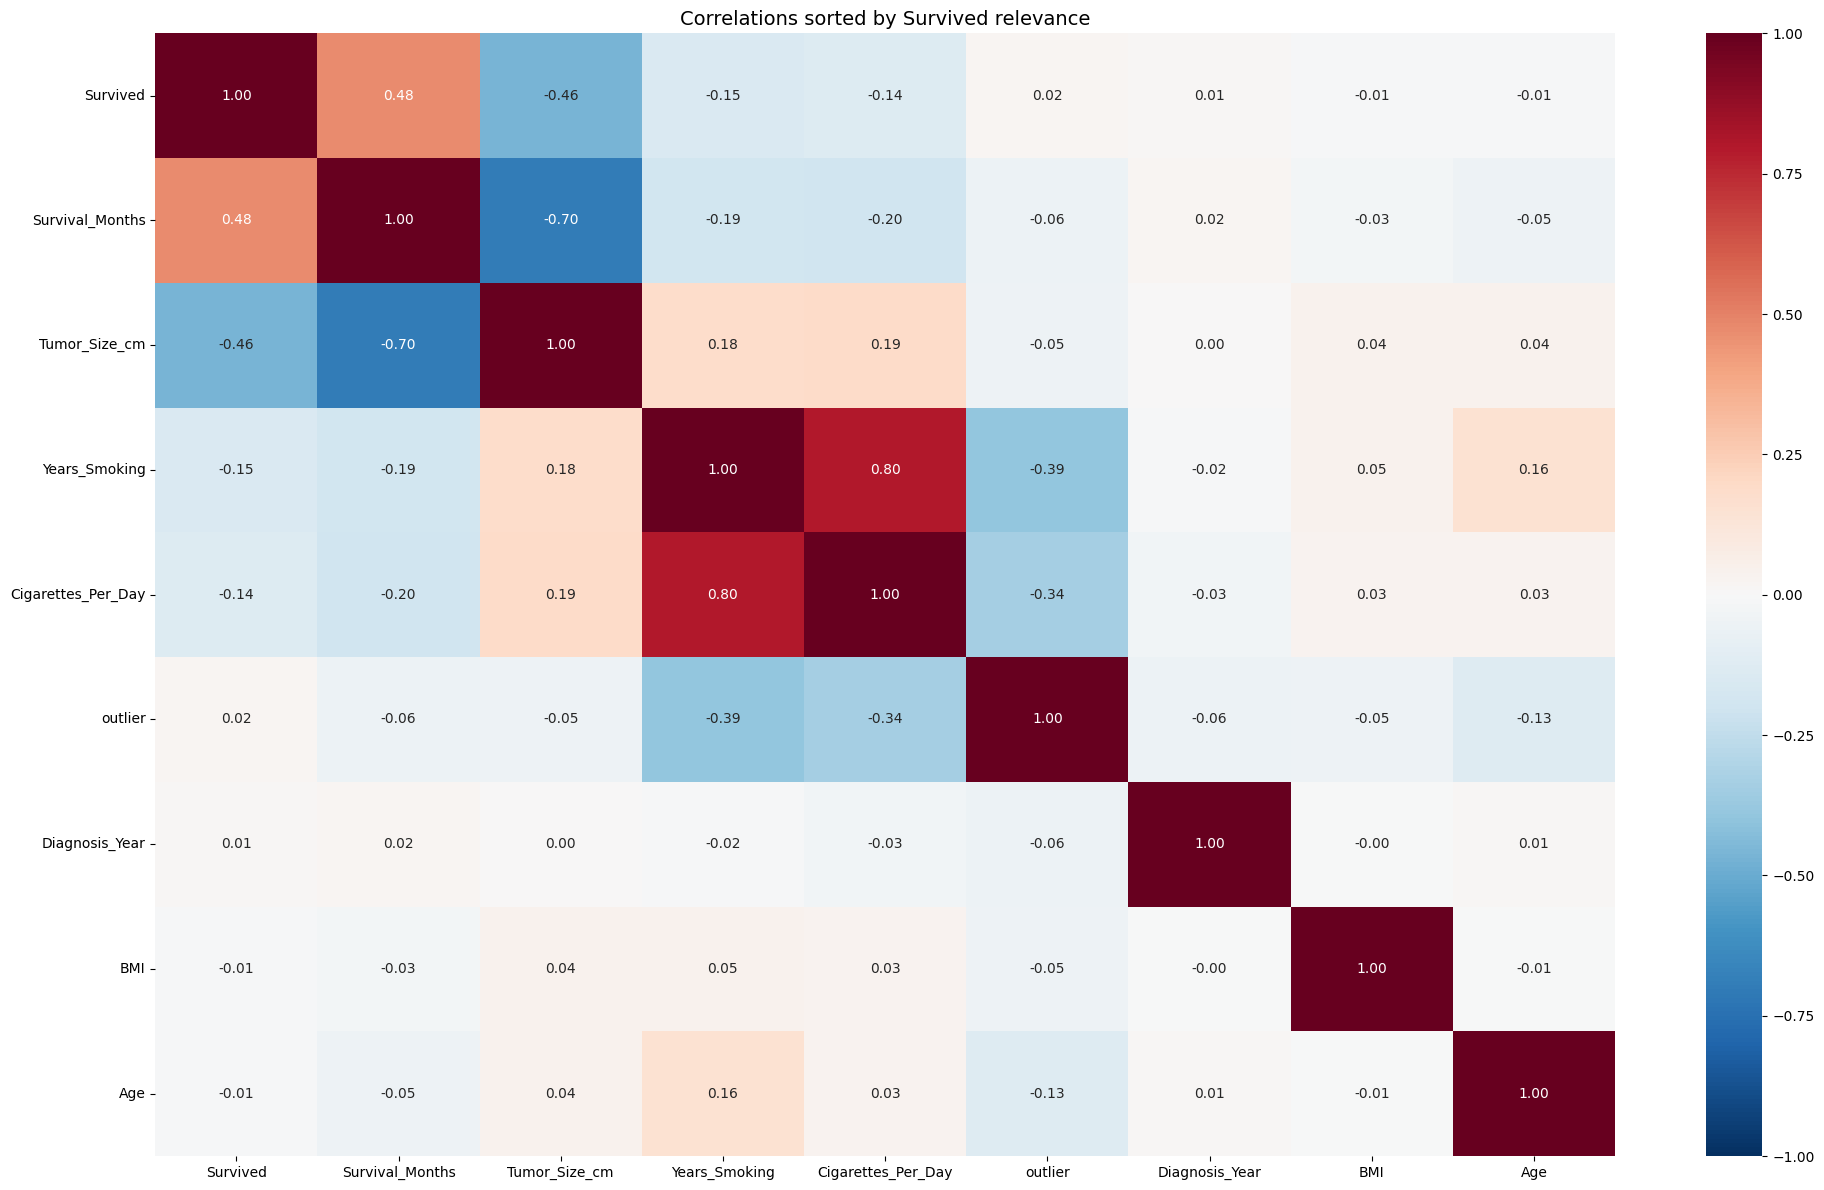

In [29]:
corr = df.assign(Survived=df['Survived'].map({'Yes': 1, 'No': 0})).corr(numeric_only=True)
target_corr = corr['Survived'].abs().sort_values(ascending=False)
sorted_cols = target_corr.index

plt.figure(figsize=(20, 12))
sns.heatmap(corr.loc[sorted_cols, sorted_cols], 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1
            )
plt.title('Correlations sorted by Survived relevance', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Cramér's V for categorical vs Survived
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

cat_survived_assoc = {
    col: cramers_v(df[col], df['Survived'])
    for col in cat_cols.columns
  }
pd.Series(cat_survived_assoc).sort_values(ascending=False)

Survived                   0.998568
Cancer_Stage               0.573548
Treatment                  0.404462
Metastasis                 0.400596
Diagnosis_Method           0.213366
Country                    0.200977
Smoking_Status             0.160926
Genetic_Mutation           0.105053
Chronic_Lung_Disease       0.090069
NSCLC_Subtype              0.070564
Shortness_of_Breath        0.067558
Chest_Pain                 0.067440
Coughing_Blood             0.064959
Cancer_Type                0.063287
Air_Pollution_Exposure     0.061044
Weight_Loss                0.058362
Gender                     0.056545
WHO_Region                 0.047911
Secondhand_Smoke           0.047790
Asbestos_Exposure          0.042909
Fatigue                    0.041902
Wheezing                   0.036759
Coughing                   0.030259
Alcohol_Use                0.026688
Family_History             0.022342
Exercise_Frequency         0.019465
Radon_Exposure             0.014873
Recurrent_Infections       0